# Problem Statement

In this project, the goal is to develop a regression model to accurately predict the insurance costs for individual customers based on their demographic and lifestyle attributes. The dataset includes critical factors such as age, BMI, number of children, smoking status, gender, and geographic region, which all contribute to the overall cost of insurance. By building this predictive model, the insurance company can assess risk more accurately, personalize premium pricing, and optimize its pricing strategy, ensuring both competitiveness in the market and profitability. The model will also help identify the key factors that significantly influence insurance costs, enabling targeted customer engagement and risk mitigation strategies.

<center><img src="https://www.canarahsbclife.com/content/dam/choice/blog-inner/images/what-is-insurance-meaning-and-benefits-of-insurance.jpg" width=500/></center>

**Content**  
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.



**Dataset Description:**  
- `age`: Age of the customer (numerical value)

- `sex`: Sex of the customer (Male/Female)

- `bmi`: Bmi ratio of the customer (numberical value)

- `children`: Number of childern (numerical value)

- `smoker`: Is the customer smokes or not (Yes/No)

- `Region`: where did customer located (southeast, southwest, northeast, northwest)
- `expenses`: total medical expenses charged to the individual policyholder


# STEP 1: Import Necessary Libraries & Modules

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import os

# STEP 2: Read Dataset from Google Drive

In [ ]:
# Load the data

# 1. Define your localized Git structure path
data_path = "data/Insurance.csv"

# 2. Smart fallback if running on Google Colab
if not os.path.exists(data_path):
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    data_path = "/content/drive/MyDrive/Colab Notebooks/Insurance.csv"

# 3. Load the data using the resolved path
data = pd.read_csv(data_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# View the data
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:

df.isnull().sum() # we see there are no null values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


<Axes: >

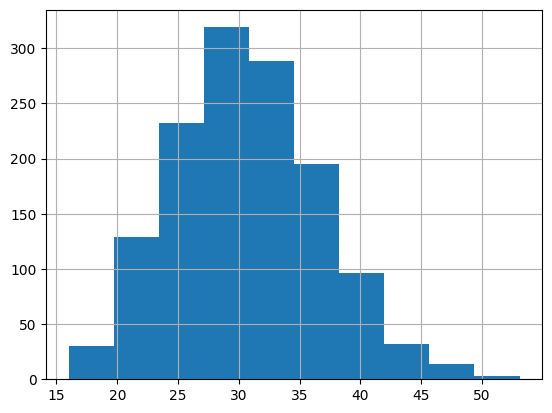

In [ ]:
df['bmi'].hist() # we see almost normal distribution for bmi and its right squewed

<Axes: >

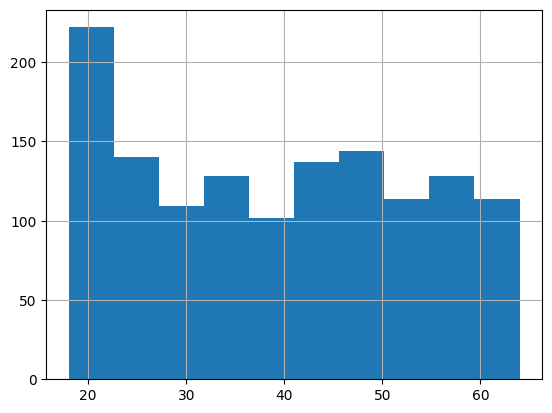

In [ ]:
df['age'].hist() #we see there are relatively more younger folks who are in 20's compared to other age groups .
                  #Rest all gorups are almost uniformly distibuted

# STEP 3: EDA

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing data to uncover patterns, detect anomalies, test hypotheses, and check assumptions. It helps in understanding the underlying structure of the data before applying modeling techniques.

## 3.1 Check the distribution of `bmi` and list down your observtions


In [ ]:
df['bmi'].mean()

np.float64(30.66547085201794)

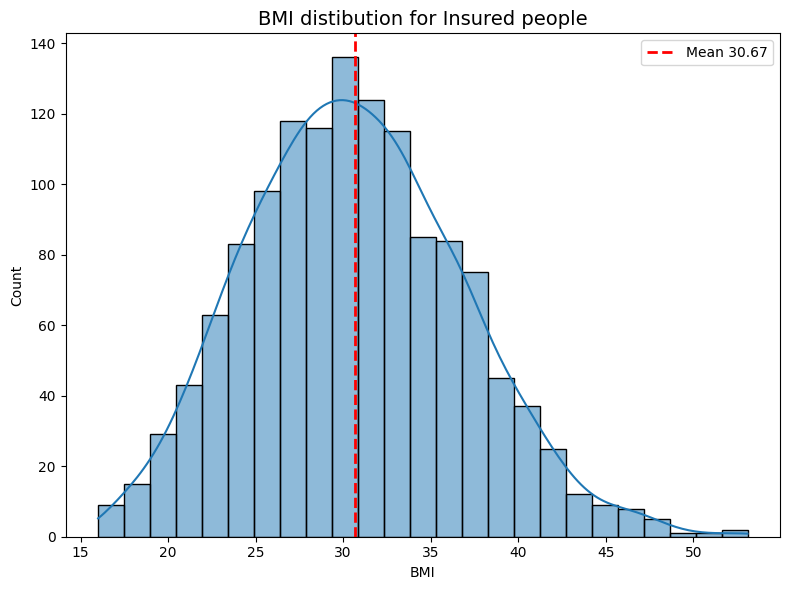

In [ ]:
# Create a bmi histogram to see the disribution of bmi
plt.figure(figsize=(8,6))
sns.histplot(data=df,x='bmi',bins='fd',kde=True)
plt.axvline(df['bmi'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean {df['bmi'].mean():.2f}')
plt.title("BMI distibution for Insured people",fontsize=14)
plt.xlabel("BMI")

plt.legend()
plt.tight_layout()
plt.show()

# Use histplot from sns library


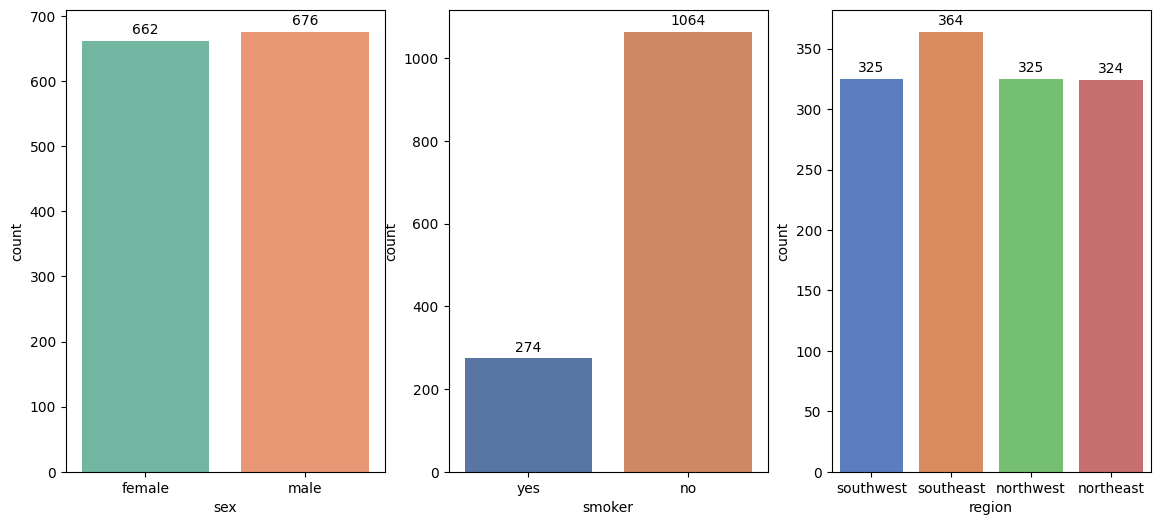

In [ ]:
# Visualize the distribution of categorical variables

fig,axes=plt.subplots(1,3,figsize=(14,6))
axes=axes.flatten()
sns.countplot(data=df,x=df['sex'],hue=df['sex'],palette="Set2",ax=axes[0]) # we see almost same number of male vs females
sns.countplot(data=df,x=df['smoker'],hue=df['smoker'],palette="deep",ax=axes[1]) # we see large number of non-smokers vs  smokers
sns.countplot(data=df,x=df['region'],hue=df['region'],palette="muted",ax=axes[2]) # we see all 4 regions are  uninormly distibuted with more number in southeast
# 2. Cleanly label all subplots at once
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3)


## 3.2 Find the distribution of all the categorical variables and list down your observations.

*Hint: Use pie chart for this visualization*

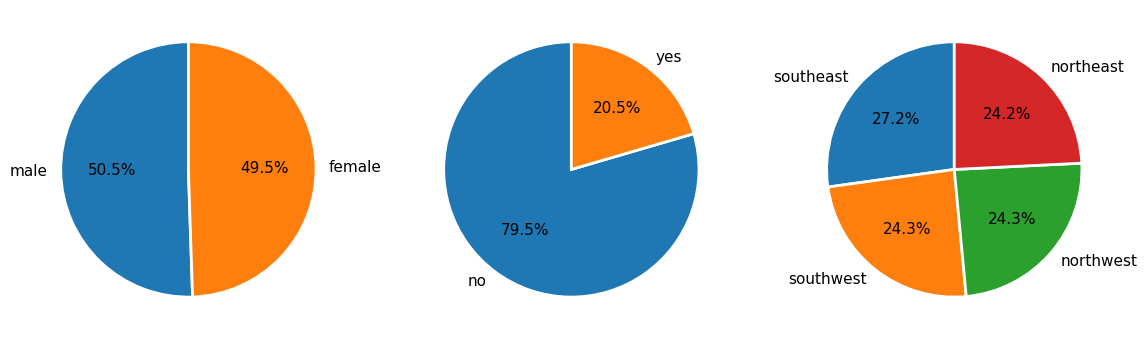

In [ ]:
# Visualize the distribution of categorical variables

# Create a list of the categorical columns
cat_cols=df.select_dtypes(include='object').columns.to_list()

# Create a subplot with 1 row and 3 columns
fig,axes=plt.subplots(1,3,figsize=(14,6))
# Generate pie charts for the categorical columns
for i,col in enumerate(cat_cols):
  # Get the value counts for the specific column
  counts = df[col].value_counts()
  ax=axes[i]
  #%: Starts the format definition.
  #1: Indicates the minimum number of digits before the decimal point and .1: Specifies that exactly 1 digit should appear after the decimal point
  #%% escapes to shwo % symbol
  ax.pie(counts,
         labels=counts.index,
         autopct='%1.1f%%',
         startangle=90,
         textprops={'fontsize': 11},
         wedgeprops={'edgecolor': 'white', 'linewidth': 2}) # Clean white dividers)  #starts on top 90degree



# Adjust the layout to avoid overlap



## 3.3 Check the relationship between the variables `smoker`, `age`, `expenses`

*Hint: Use scatter plot to find the relationship between the variables.*

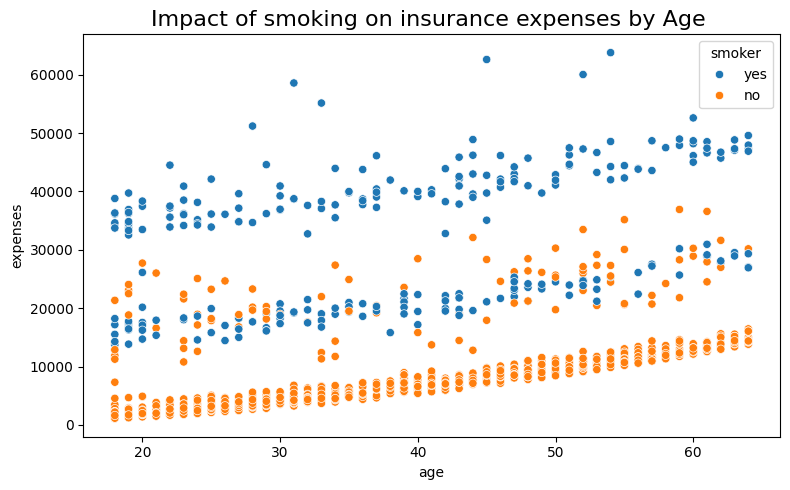

In [ ]:
# Checking the relationship between smoker, age, and expenses

fig=plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='age',y='expenses',hue='smoker')
plt.title("Impact of smoking on insurance expenses by Age ",fontsize=16)
plt.tight_layout()
plt.show()


1. The Cost of Smoking (The Massive Gap):Smokers (blue dots) dominate the top tiers of the chart. Their expenses almost never drop below $15,000, even at age 18.

2. Non-smokers (orange dots) make up the vast majority of the lowest, most predictable expense band (under $15,000).

The "Three-Tier" Risk Phenomenon:
  1. Bottom Band ($0 – $15k): Consists strictly of healthy non-smokers. Expenses increase linearly and slowly with age due to natural aging risks.
  2. Middle Band ($15k – $30k): Contains a mix of non-smokers (likely with pre-existing conditions or high BMIs) and smokers with fewer complications.
  3. Top Band ($30k – $65k): Populated exclusively by smokers. These are high-risk individuals experiencing severe, compounding health issues or high hospitalization expenses.

Age vs. Expense Correlation:
  1. Age has a steady, positive upward slope in all three bands. As age increases, baseline expenses increase incrementally.
  2. However, behavior (smoking) has a exponentially larger impact on expenses than age. A 20-year-old smoker frequently incurs higher insurance costs ($35k–$40k) than a 60-year-old non-smoker ($15k).

> Add blockquote



In [ ]:
# Grouping data by 'smoker' and 'age' to calculate the mean expenses for each group

df.groupby(by=['smoker','age'])['expenses'].mean().reset_index()


,smoker,age,expenses
0,no,18,3215.162632
1,no,19,3536.713200
2,no,20,3673.113000
3,no,21,3813.530385
4,no,22,2551.017727
...,...,...,...
89,yes,60,48115.448000
90,yes,61,38578.793333
91,yes,62,37084.607500
92,yes,63,40331.786000


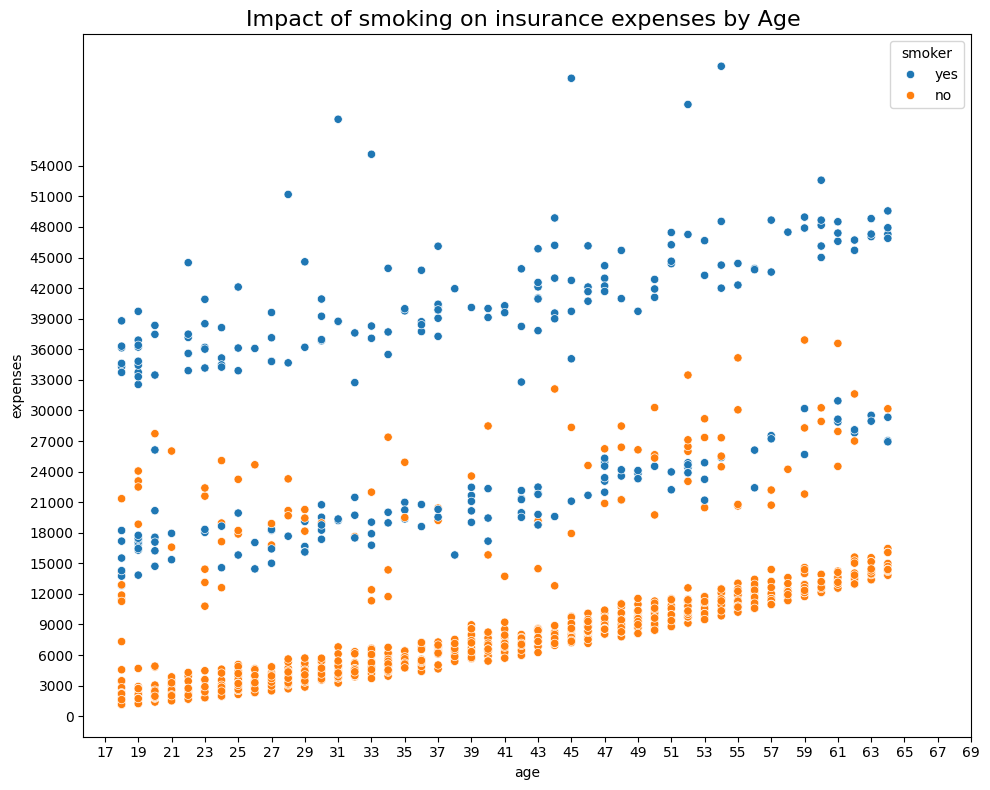

In [ ]:
# Setting up the plot


# Creating a scatter plot with 'age' on the x-axis, 'expenses' on the y-axis, and different colors for 'smoker' status
# Customizing the y-axis ticks to range from 0 to 55,000 with increments of 3,000
# Customizing the x-axis ticks to range from age 17 to 70 with increments of 2 years
# Display the plot
fig=plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='age',y='expenses',hue='smoker')
plt.title("Impact of smoking on insurance expenses by Age ",fontsize=16)
plt.yticks(np.arange(0,55000,3000))
plt.xticks(np.arange(17,70,2))
plt.tight_layout()
plt.show()


## 3.3 Check the relationship between the variables `smoker`, `bmi`, `expenses`

*Hint: Use scatter plot to find the relationship between the variables.*

In [ ]:
# Checking the relationship between smoker, BMI, and expenses

# Grouping the data by 'smoker' and 'bmi' to calculate the mean expenses for each group
df.groupby(by=['smoker','bmi'])['expenses'].mean().reset_index()


,smoker,bmi,expenses
0,no,16.0,1694.800
1,no,16.8,4904.000
2,no,17.3,5305.305
3,no,17.4,2680.230
4,no,17.5,1621.340
...,...,...,...
417,yes,45.5,42112.240
418,yes,46.2,45863.210
419,yes,47.4,63770.430
420,yes,47.6,46113.510


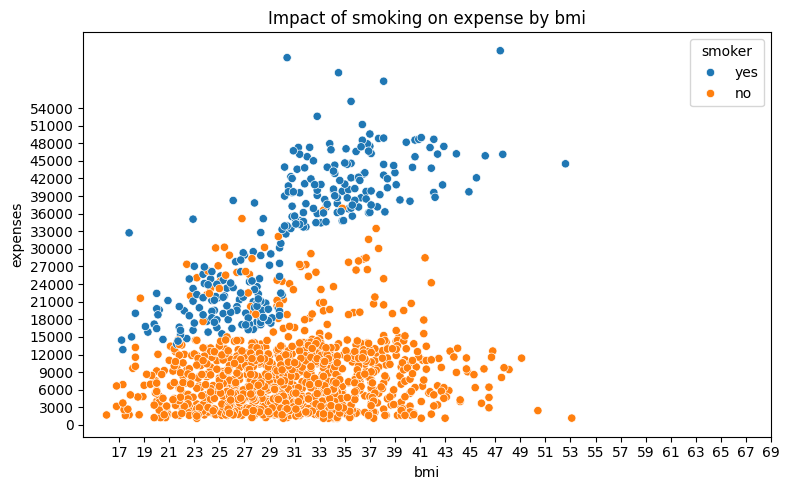

In [ ]:
# Setting up the plot


# Creating a scatter plot with 'bmi' on the x-axis, 'expenses' on the y-axis, and different colors for 'smoker' status


# Customizing the y-axis ticks to range from 0 to 55,000 with increments of 3,000

# Customizing the x-axis ticks to range from BMI 17 to 70 with increments of 2 units


# Display the plot

fig=plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='bmi',y='expenses',hue='smoker')
plt.title("Impact of smoking on expense by bmi")
plt.yticks(np.arange(0,55000,3000))
plt.xticks(np.arange(17,70,2))
plt.tight_layout()
plt.show()

1. Smoking is the Single Largest Driver of High Expenses
    The Gap: There is a clear vertical separation between the blue dots (smokers) and orange dots (non-smokers).
    
    The Threshold: Almost all individuals with expenses above $30,000 are smokers. Non-smokers rarely cross the $15,000 to $30,000 threshold, regardless of their BMI.
2. High BMI Combined with Smoking Multiplies Expenses
    The Exponential Jump: For smokers (blue dots), look at what happens around a BMI of 30:
    BMI under 30: Expenses cluster between $15,000 and $30,000.
    
    BMI over 30: Expenses immediately skyrocket, clustering between $35,000 and $55,000.
    
    The Interaction: This indicates a severe compounding health risk (and financial cost) when a person both smokes and crosses into the medically defined obesity range (BMI \(\ge \) 30).
   
    
3. For Non-Smokers, BMI Has a Very Minimal Impact on Expenses
    
    The Baseline: The vast majority of non-smokers (orange dots) remain tightly packed at the bottom of the chart, with expenses safely below $15,000.
    
    The Flat Trend: Whether a non-smoker has a low BMI of 18 or a very high BMI of 45+, their baseline expenses do not experience the aggressive vertical jump seen in the smoking population.

## 3.4 Find the outliers (if any) in the numerical variables

*Hint: Use box plot and calculate IQR to detect the outliers.*

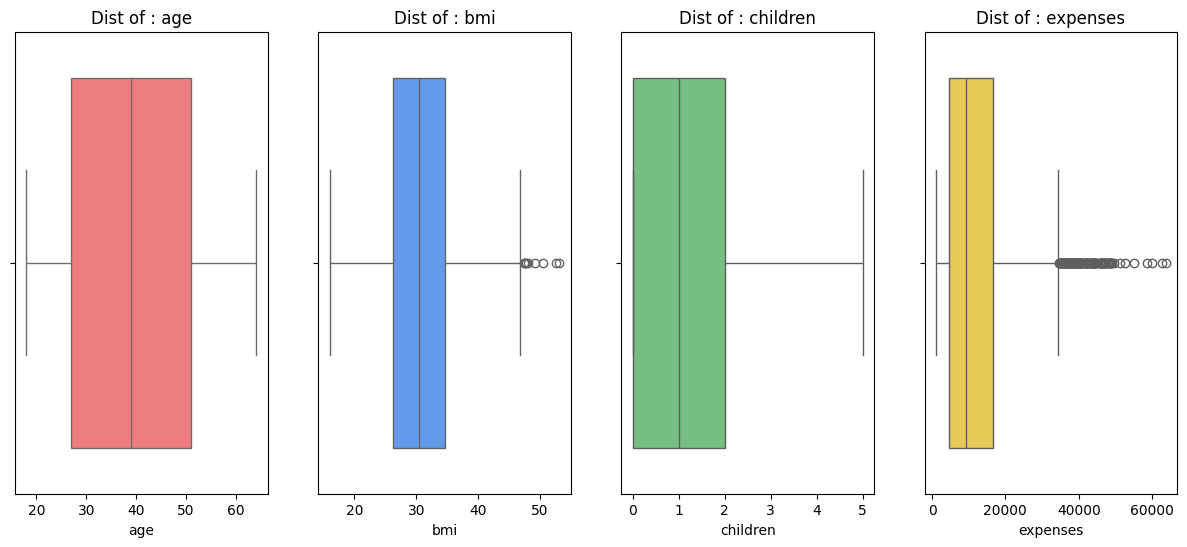

In [ ]:
# Identify numerical columns for outlier detection
numeric_columns=df.select_dtypes(exclude='object').columns.to_list()

fig,axes=plt.subplots(nrows=1,ncols=4,figsize=(15,6))
axes.flatten()
# 1. Define a list of 4 distinct colors
colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D']

# Visualizing Outliers Using Box Plots
for i, col in enumerate(numeric_columns):
  sns.boxplot(data=df,x=col,ax=axes[i],color=colors[i],patch_artist=True)
  axes[i].set_title(f"Dist of : {col}")
  axes[i].set_ylabel('')

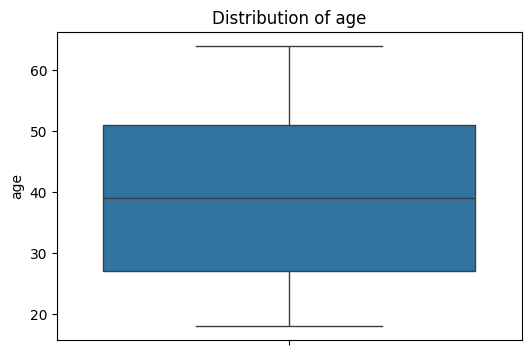

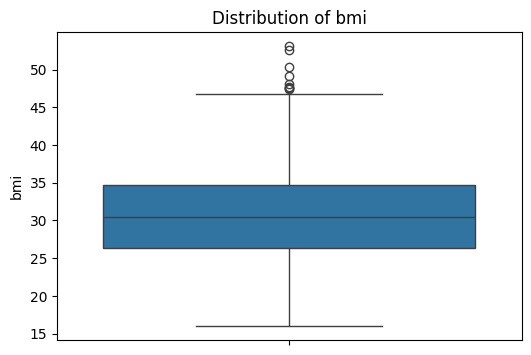

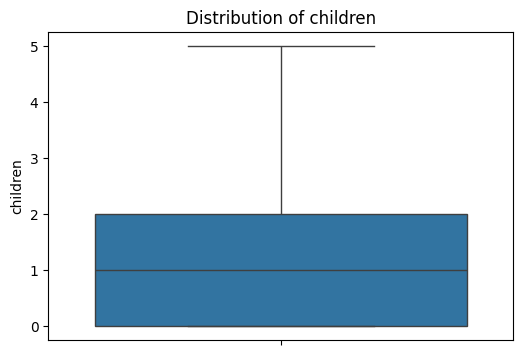

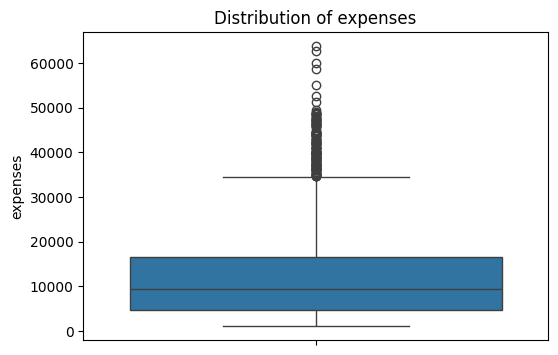

In [ ]:
#version without subplots but loop and create new plot each time
numeric_columns=df.select_dtypes(exclude='object').columns.to_list()

for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=df[col])
  plt.title(f"Distribution of {col}")
  plt.show()

1. Dist of : age (Uniform & Well-Distributed)Symmetric:

    The distribution is highly balanced with no skewness.

    Range: The dataset covers individuals from roughly 18 to 64 years old.
  
    Median: The median age sits right around 39 years old.

    No Outliers: The data is evenly spread across the working-age population.

2. Dist of : bmi (Centrally Clustered with High Outliers)

    Median: The median BMI is approximately 30, which falls right on the border line of the medically defined obesity range.
  
    Normal Spread: Most people fall between a BMI of 26 and 35 (the blue box).
  
    Outliers: There are several high-BMI outliers on the far right stretching from 47 to 53.

3. Dist of : children (Skewed Lower)Concentrated:
  The data is heavily concentrated on the lower end.
  
    The Bulk: Most individuals in this dataset have between 0 and 2 children (IQR).
  
    Median: The median number of children is 1.
  
    Maximum: While some families have up to 5 children, it is sparse enough to stretch the right whisker but not classified as statistical outliers.

4. Dist of : expenses (Highly Skewed / Severe Inequality)
    Extreme Right-Skew: This is a classic heavily skewed distribution.Low Baseline:
  
    The median expense is quite low, sitting around $10,000, and 75% of the data (the blue box) stays below roughly $17,000.
  
    Massive Outlier Trail: There is a heavy, continuous trail of outliers starting around $35,000 and reaching above $60,000. This indicates a specific subgroup of the population incurs massive medical costs (likely the high-BMI smokers identified in your previous scatter plot).



 key=age 
 value is : 
 Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, expenses]
Index: []

 key=bmi 
 value is : 
       age     sex   bmi  children smoker     region  expenses
116    58    male  49.1         0     no  southeast  11381.33
286    46  female  48.1         2     no  northeast   9432.93
401    47    male  47.5         1     no  southeast   8083.92
543    54  female  47.4         0    yes  southeast  63770.43
847    23    male  50.4         1     no  southeast   2438.06
860    37  female  47.6         2    yes  southwest  46113.51
1047   22    male  52.6         1    yes  southeast  44501.40
1088   52    male  47.7         1     no  southeast   9748.91
1317   18    male  53.1         0     no  southeast   1163.46

 key=children 
 value is : 
 Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, expenses]
Index: []

 key=expenses 
 value is : 
       age     sex   bmi  children smoker     region  expenses
14     27    male  42.1         0 

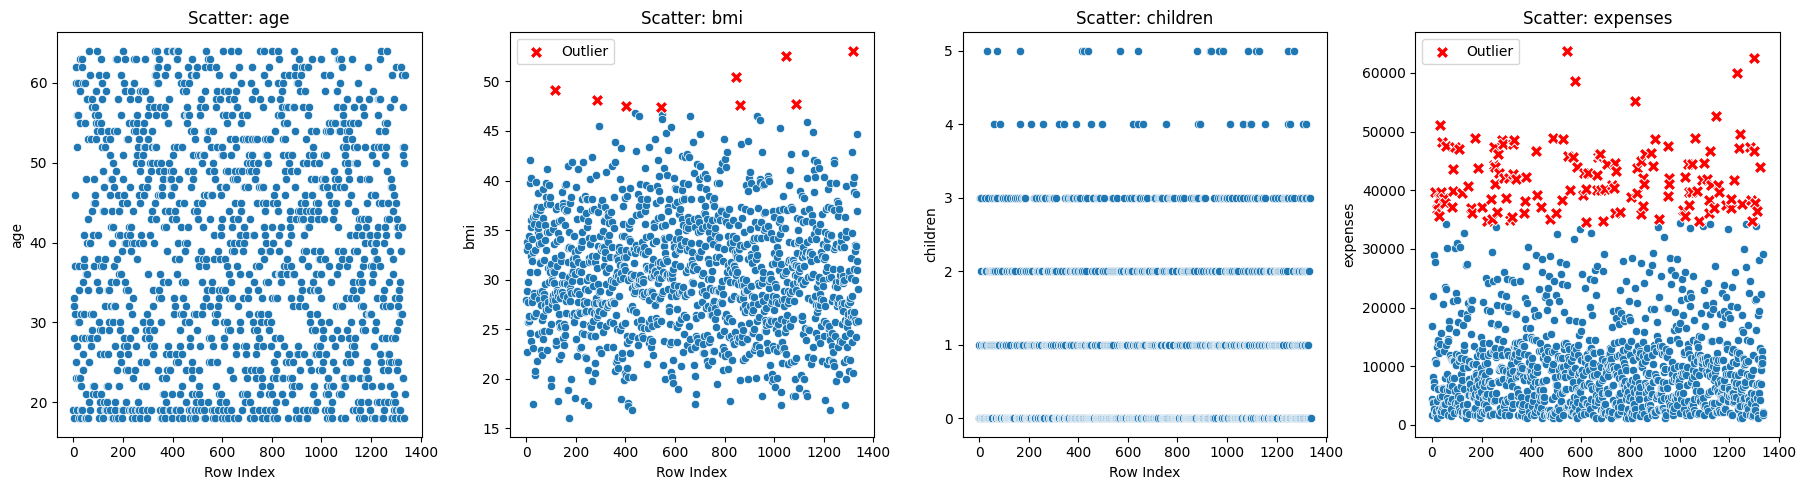

In [ ]:


# Identifying Outliers Using the IQR Method
# Initialize a dictionary to store outliers
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for the column
# Compute the Interquartile Range (IQR)
# Define the lower and upper bounds to detect outliers
# Identify outliers that fall outside the lower and upper bounds
# Print the detected outliers for each numerical feature

q1=df[numeric_columns].quantile(0.25)
q3=df[numeric_columns].quantile(0.75)
iqr_df=q3-q1

def get_outliers(col):
  lower_bound= q1[col]- 1.5* iqr_df[col]
  upper_bound= q3[col] + 1.5* iqr_df[col]
  mask= ((df[col]<  lower_bound )| (df[col] >  upper_bound))
  return df[mask]

outliers={col:get_outliers(col) for col in numeric_columns}

# to check if any of cols do not have outliers : ie empty value for dataframe: [k for k,v in outliers.items() if v.empty]

#print outliers:
for k,v in outliers.items():
  print(f'\n key={k} \n value is : \n {v}')



# Visualizing Outliers with Scatter Plots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 5))
axes = axes.flatten()

for i,col in enumerate(numeric_columns):
  sns.scatterplot(data=df,x=df.index,y=col,ax=axes[i])
  outlier_df=outliers[col]
  if not outlier_df.empty:
    sns.scatterplot(data=outlier_df,x=outlier_df.index,y=col,ax=axes[i],marker='X',color='red',s=80, label='Outlier')
    axes[i].legend()
  axes[i].set_title(f"Scatter: {col}")
  axes[i].set_xlabel("Row Index")




plt.tight_layout()
# Display the scatter plots with highlighted outliers


## 3.5 Do a complete correlation analysis of the entire data

*Hint: Create dummy variables for all the categorical variables and then use a heatmap to do the correlation analysis.*

In [ ]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Identify categorical and numerical columns
categorical_columns=df.select_dtypes(include='object').columns.to_list()
numerical_columns=df.select_dtypes(exclude='object').columns.to_list()

# Apply one-hot encoding directly to the entire dataset
preprocesser=ColumnTransformer(
    transformers=[
        ('cat_encoder',OneHotEncoder(sparse_output=False),categorical_columns)
        ],
    remainder='passthrough'
)

#Transform the data
transformed_array=preprocesser.fit_transform(df)
new_column_names = preprocesser.get_feature_names_out()
transformed_df=pd.DataFrame(transformed_array,columns=new_column_names)
#view head of transformed_df
#print(transformed_df.head())




In [ ]:
transformed_df.head()

,cat_encoder__sex_female,cat_encoder__sex_male,cat_encoder__smoker_no,cat_encoder__smoker_yes,cat_encoder__region_northeast,cat_encoder__region_northwest,cat_encoder__region_southeast,cat_encoder__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__expenses
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.9,0.0,16884.92
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.8,1.0,1725.55
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.0,3.0,4449.46
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.7,0.0,21984.47
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.9,0.0,3866.86


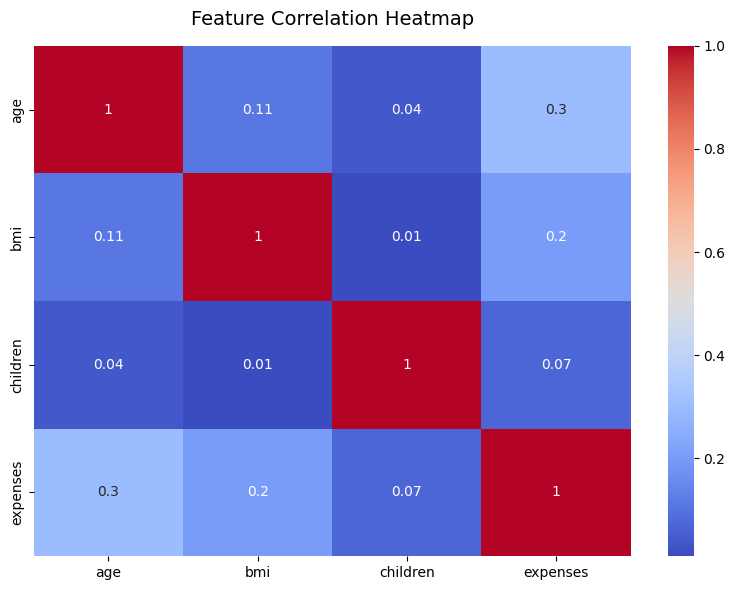

In [ ]:
# Calculate the correlation matrix
correlation_matrix=df[numeric_columns].corr().round(2)

# Print the correlation with the 'expenses' variable
correlation_matrix['expenses']

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,  # Injects the exact numerical correlation scores into cells
    cmap='coolwarm'
    )

# Title configuration
plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()

# Display the final plot
plt.show()

# STEP 4: Data Preprocessing

Data preprocessing is the crucial step of cleaning and transforming raw data into a suitable format for analysis or modeling, ensuring that the data is accurate, complete, and ready for machine learning algorithms. It helps improve model performance and accuracy by addressing issues like missing values, noise, and inconsistencies.

## 4.1 Check for any missing values & handle them if necessary

In [ ]:
# Check the dataset info

df.info() #we see no missing or nulls
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


# STEP 5: Model Building

## 5.1 Split the data into Training & Test data

*Hint: Use the dummy encoded data.*

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the target & feature variables

y=transformed_df['remainder__expenses']
X=transformed_df.drop(columns=['remainder__expenses'])
# Split into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33, random_state=42)



## 5.2 Scale the dataset

In [ ]:
# Scaling the data . From scratch lets do everything using df. leave  above steps as is and do end-end pipeline

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import set_config

#step1: Drop nulls from target
df_clean=df.dropna(subset=['expenses']) #drop nulls from target before splitting. During traing scale doesnt matter for target.

#step 2: seperate target and features
y=df_clean['expenses']
X=df_clean.drop(columns=['expenses'])

#You should not apply your feature transformation pipeline to the target variable (y).Also avoid Data lekage risk

categorical_columns=X.select_dtypes(include='object').columns.to_list()
numerical_columns=X.select_dtypes(exclude='object').columns.to_list() #make sure expenses target is not part of this. so used X instead of df

# step 3: Split into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33, random_state=42)


# step 4: Assemble transformations and impute in pipeline
numeric_transformer=Pipeline(steps=[
                                    ('imputer',SimpleImputer(strategy='median')),
                                    ('scaler',StandardScaler())
                                   ])
cat_transformer=Pipeline(steps=[
                                ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
                                ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))
                                 ])


preprocessor=ColumnTransformer(transformers=[
                                ('num',numeric_transformer,numerical_columns),
                                ('cat',cat_transformer,categorical_columns)
                                ],
                                remainder='drop'

)

#step 5: unified Pipeline . Assemble preprocesing and model
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression()) #no need of random state for regression as it will calculate same always. no randomness
])

#step 6: fit the model with traing data .
lr_pipeline.fit(X_train,y_train)

#step 7: predict on test data
lr_predictions=lr_pipeline.predict(X_test)




In [ ]:
set_config(display='text')

lr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   

In [ ]:
set_config(display='diagram')

lr_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('classifier', LinearRegression())])

In [ ]:
# Step 8: metics
from sklearn.metrics import mean_absolute_percentage_error,mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
def show_metrics(predictions):
  print(f'Mean Absolute Error:    {mean_absolute_error(y_test,predictions):.2f}')
  #print(f'Mean Squared Error:     {mean_squared_error(y_test,predictions):.2f}') #Not needed as we have RMSE below
  print(f'Root Mean Squared Error:{root_mean_squared_error(y_test,predictions):.2f}')
  print(f'Mean Absolute % Error:  {mean_absolute_percentage_error(y_test,predictions):.2f}')
  r2=r2_score(y_test,predictions)
  print(f'R  Squared Error:       {r2:.2f}')

  #compute Adjusted R2

  # n = number of test samples, p = number of features the model used
  n = len(y_test)
  p = X_test.shape[1]
  adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
  print(f'number of test samples: {n}, number of features the model used: {p}')
  print(f'Adjusted R-Squared Error:{adjusted_r2:.2f}')



In [ ]:
#show metrics

show_metrics(lr_predictions)

Mean Absolute Error:    4193.04
Root Mean Squared Error:5923.47
Mean Absolute % Error:  0.44
R  Squared Error:       0.76
number of test samples: 442, number of features the model used: 6
Adjusted R-Squared Error:0.76


In [ ]:
#step 9 retreive co-efficents , intercept and draw regression line
# 1. Extract the components out from the master pipeline container
fitted_preprocessor = lr_pipeline.named_steps['preprocessor']
fitted_model = lr_pipeline.named_steps['regressor']

# 2. Get the exact, final column names after transformation
feature_names = fitted_preprocessor.get_feature_names_out()

## Chaining the extraction and feature names into one step
#feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Retrieve the weights (coefficients) and the intercept (baseline)
coefficients = fitted_model.coef_
intercept = fitted_model.intercept_

# 4. Pair columns with their weights into a clean DataFrame for review
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("="*45)
print("          FEATURE COEFFICIENTS          ")
print("="*45)
print(coef_df.to_string(index=False))
print("="*45)

# 5. Construct and print the best-fit regression line equation
equation_terms = [f"({coef:.2f} * {name})" for coef, name in zip(coefficients, feature_names)]
regression_equation = f"Expenses = {intercept:.2f} + " + " + ".join(equation_terms)

print("\n" + "="*45)
print("       BEST-FIT REGRESSION EQUATION     ")
print("="*45)
print(regression_equation)
print("="*45 + "\n")


          FEATURE COEFFICIENTS          
              Feature   Coefficient
      cat__smoker_yes  11850.166582
             num__age   3715.137853
             num__bmi   2076.403814
cat__region_northeast    507.015373
        num__children    448.085142
cat__region_northwest    168.044423
        cat__sex_male     60.662515
      cat__sex_female    -60.662515
cat__region_southwest   -295.638051
cat__region_southeast   -379.421745
       cat__smoker_no -11850.166582

       BEST-FIT REGRESSION EQUATION     
Expenses = 20249.59 + (3715.14 * num__age) + (2076.40 * num__bmi) + (448.09 * num__children) + (-60.66 * cat__sex_female) + (60.66 * cat__sex_male) + (-11850.17 * cat__smoker_no) + (11850.17 * cat__smoker_yes) + (507.02 * cat__region_northeast) + (168.04 * cat__region_northwest) + (-379.42 * cat__region_southeast) + (-295.64 * cat__region_southwest)



## 5.3 Fit the Linear Regression Model

In [ ]:
# Initialize the Linear Regression model

# Fit the model to the training data

# Make predictions on the test data


## 5.4 Check the Coefficients


In [ ]:
# Print the best fit regression line


## 5.5 Evaluate the model - Find MAE, MSE, R-squared

In [ ]:
# Evaluate the model


# Print the evaluation metrics


## 5.6 Calculate Adjusted R-squared value using the formula

Here's the Adjusted R-squared formula formatted for Google Colab markdown:

```
Adjusted R-squared (R²ᴀᴅᴊ) = 1 - [(1 - R²) * (n - 1)] / (n - k - 1)
```

### Where:
- **R²** is the R-squared value of the model.
- **n** is the total number of observations.
- **k** is the number of independent variables (predictors) in the model.



In [ ]:
# Calculate the number of observations (n) and the number of predictors (p)

# Calculate the Adjusted R-squared value

# Print the Adjusted R-squared value



## 5.7 Visualize the predictions

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the predictions

# Create a scatter plot of actual vs. predicted expenses
def predictions_scatter_plot(y_test,predictions):
  plt.figure(figsize=(8,6))
  # 1. Plot the actual vs predicted values
  # X-axis = Actual, Y-axis = Predicted
  sns.scatterplot(
      x=y_test,
      y=predictions,
      alpha=0.6,          # Adds transparency to spot overlapping dense data points
      color='#1f77b4',    # Professional slate blue
      edgecolor='w'
  )

  # 2. Add the "Perfect Prediction" reference line (y = x)
  # We find the min and max coordinates across the data to span the line perfectly
  min_val = min(y_test.min(), predictions.min())
  max_val = max(y_test.max(), predictions.max())

  #The plt.plot() function expects coordinates in this format:
  #plt.plot([x_start, x_end], [y_start, y_end])
  plt.plot(
      [min_val, max_val],
      [min_val, max_val],
      color='red',
      linestyle='--',
      linewidth=2,
      label='Perfect Prediction (y=x)'
  )

  # 3. Labeling and formatting
  plt.title('Actual vs. Predicted Expenses', fontsize=14, pad=15, fontweight='bold')
  plt.xlabel('Actual Expenses ($)', fontsize=12)
  plt.ylabel('Predicted Expenses ($)', fontsize=12)
  plt.legend(loc='upper left')

  # Ensure the plot layout is clean and display it
  plt.tight_layout()
  plt.show()

# Add a line plot representing the ideal case where predicted values equal actual values

# Add titles and labels to the plot

# Display the plot


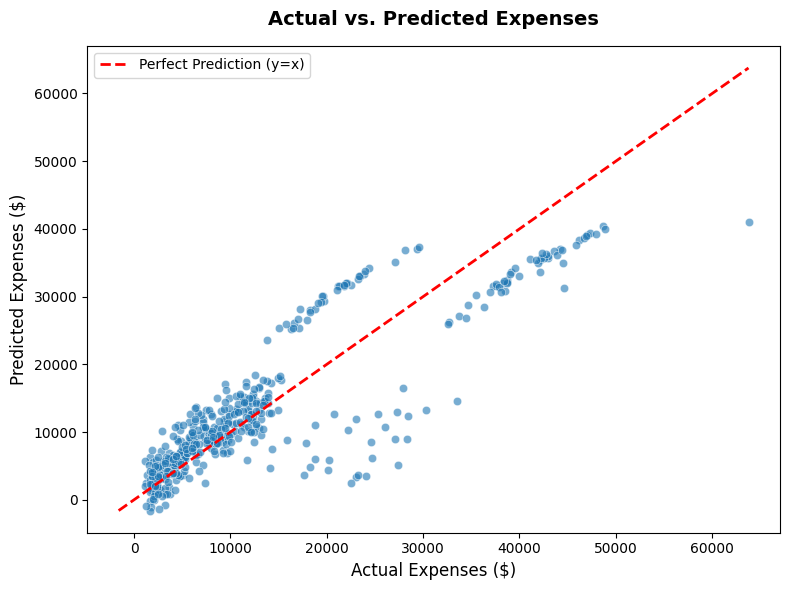

In [ ]:
#see the predicitons of lr model:
predictions_scatter_plot(y_test,lr_predictions)

In [ ]:
#Residual plot
def show_residual_plot(predictions,y_test):
  # Configure the plot window
  plt.figure(figsize=(10, 6))

  # Use sns.residplot by passing predictions vs actual test values
  # lowess=True draws a smooth trendline to help spot hidden patterns in your errors
  sns.residplot(
      x=predictions,
      y=y_test,
      lowess=True,
      color="#0284c7",
      scatter_kws={'alpha': 0.6, 'edgecolor': 'w'},
      line_kws={'color': '#ef4444', 'lw': 2.5, 'label': 'Error Trendline'}
  )

  # Customize the chart aesthetics
  plt.title("Insurance Model Diagnostics: Seaborn Residual Plot", fontsize=14, pad=15)
  plt.xlabel("Predicted Insurance Expenses ($)", fontsize=11)
  plt.ylabel("Residuals / Errors ($)", fontsize=11)
  plt.grid(True, linestyle=":", alpha=0.5)
  plt.legend()

  # Display the plot cleanly
  plt.tight_layout()
  plt.show()

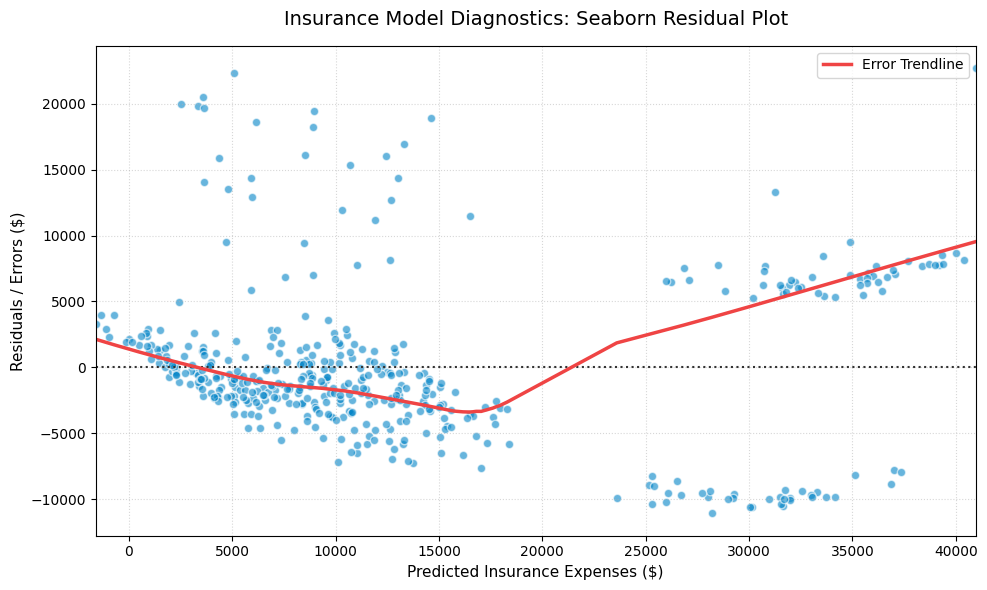

In [ ]:
#residual plot for lr model
show_residual_plot(lr_predictions,y_test)

The lowess=True Parameter: This tells Seaborn to automatically calculate a locally weighted scatterplot smoothing line.

If this red trendline stays perfectly flat and glued to the center 0 line, your model is structurally sound.
If it dips or bends, your model is systematically mispricing certain brackets of people. we see this pattern in above data


In [ ]:
#Try few other models using gridsearch cv and compare
from sklearn.ensemble import RandomForestRegressor


rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(random_state=42))
])

#step 6: fit the model with traing data .
rf_pipeline.fit(X_train,y_train)

#step 7: predict on test data
rf_predictions=rf_pipeline.predict(X_test)

In [ ]:
set_config(display="diagram")
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('classifier', RandomForestRegressor())])

Mean Absolute Error:    2660.94
Root Mean Squared Error:4801.69
Mean Absolute % Error:  0.32
R  Squared Error:       0.84
number of test samples: 442, number of features the model used: 6
Adjusted R-Squared Error:0.84


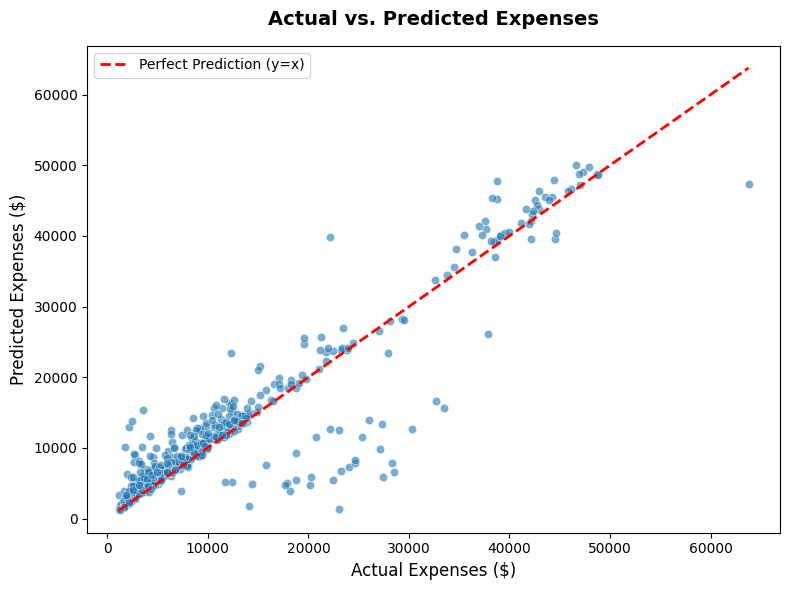

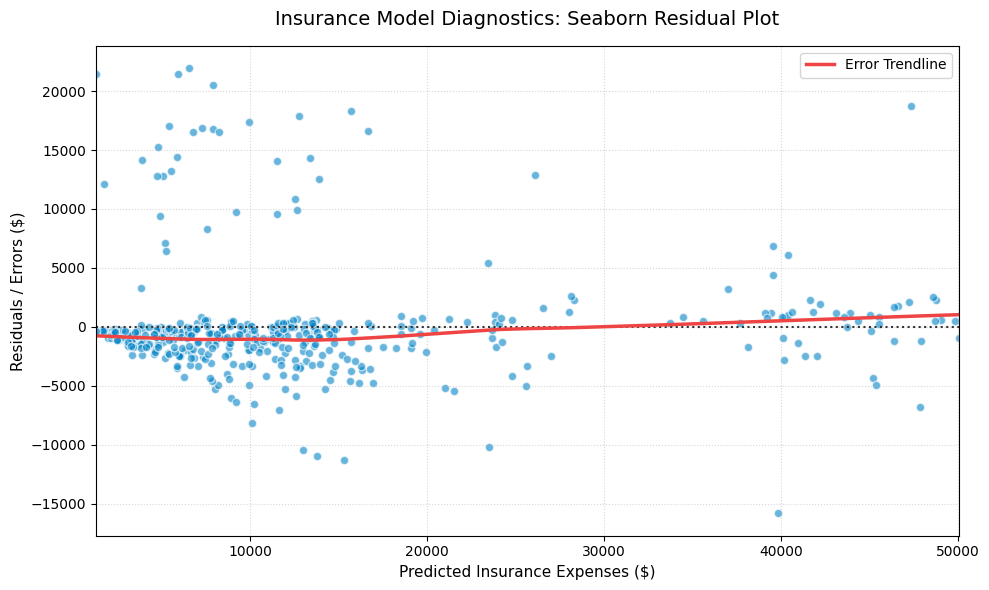

In [ ]:
#show metrics , plot predictions, residual plot

show_metrics(rf_predictions)
predictions_scatter_plot(y_test,rf_predictions)
show_residual_plot(rf_predictions,y_test)


In [ ]:
#print hyperparamaters used:
import pprint

# 1. Extract the LGBMRegressor step from the pipeline
rf_model=rf_pipeline.named_steps['regressor']

# 2. Retrieve all internal hyperparameters as a dictionary
rf_params=rf_model.get_params()

# 3. Print the complete dictionary beautifully
print("--- All Internal LGBMRegressor Hyperparameters ---")
pprint.pprint(rf_params)

--- All Internal LGBMRegressor Hyperparameters ---
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


This looks very good compared to the logistic regression residuals.

In [ ]:
#LGBGM
from lightgbm import LGBMRegressor

lbg_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LGBMRegressor(random_state=42))
])

#step 6: fit the model with traing data .
lbg_pipeline.fit(X_train,y_train)

#step 7: predict on test data
lgb_predictions=rf_pipeline.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 896, number of used features: 11
[LightGBM] [Info] Start training from score 13379.688378


In [ ]:
set_config(display="diagram")
lbg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('classifier', LGBMRegressor(random_state=42))])

Mean Absolute Error:    2660.94
Root Mean Squared Error:4801.69
Mean Absolute % Error:  0.32
R  Squared Error:       0.84
number of test samples: 442, number of features the model used: 6
Adjusted R-Squared Error:0.84


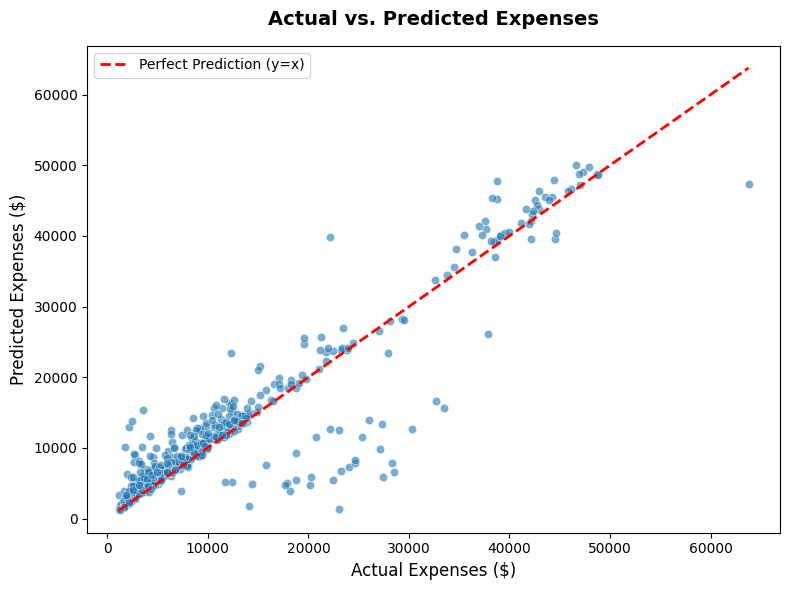

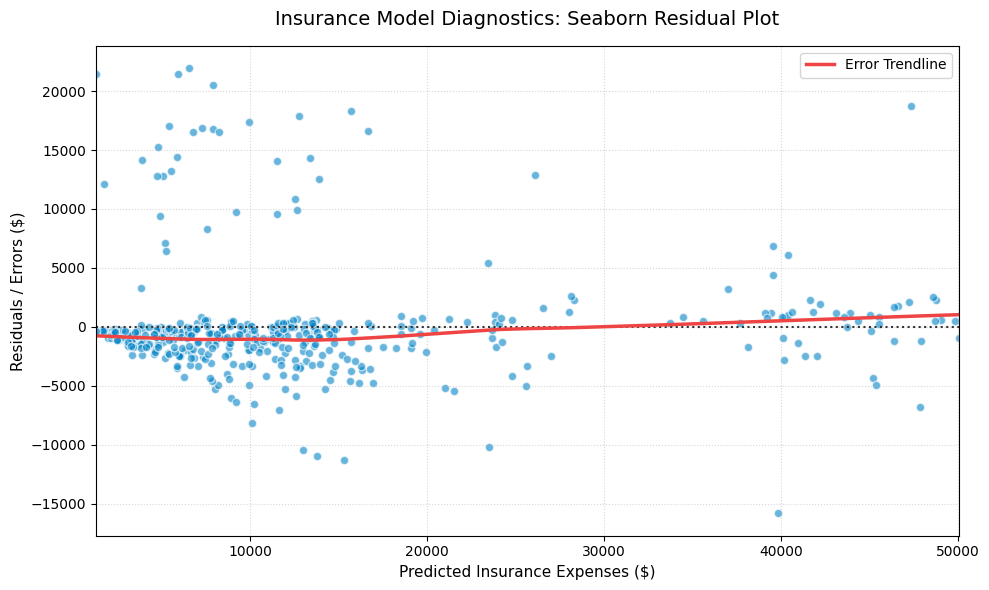

In [ ]:
#show metrics , plot predictions, residual plot

show_metrics(lgb_predictions)
predictions_scatter_plot(y_test,lgb_predictions)
show_residual_plot(lgb_predictions,y_test)

In [ ]:
#print hyperparamaters used:
import pprint

# 1. Extract the LGBMRegressor step from the pipeline
lgbm_model=lbg_pipeline.named_steps['regressor']

# 2. Retrieve all internal hyperparameters as a dictionary
lgbm_params=lgbm_model.get_params()

# 3. Print the complete dictionary beautifully
print("--- All Internal LGBMRegressor Hyperparameters ---")
pprint.pprint(lgbm_params)

--- All Internal LGBMRegressor Hyperparameters ---
{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}
